The time-independent Schrödinger equation for a particle of mass $ m $ in one dimension, confined to an interval of length $ L $ under potential $ V(x) $, is given by

$$
    -\frac{\hbar ^ 2}{2 m} \frac{d ^ 2\psi}{dx ^ 2} + V(x) \psi = E \psi, \qquad \psi(0) = \psi(L) = 0
$$

We transform it into dimensionless form by defining:

- $ x' = x / L \in [0 , 1] $
- $ E_0 = \hbar ^ 2 / (2 m L ^ 2) $
- $ V'(x') = V(x = x' L) / E_0 $
- $ E' = E / E_0 $
- $ \psi'(x') = \sqrt{L} \, \psi(x = x' L) $

The equation simplifies to:

$$
    - \frac{d ^ 2 \psi'}{dx'^2} + V'(x') \psi' = E' \psi', \qquad \psi'(0) = \psi'(1) = 0
$$

Let's solve it for some potentials $V'$ using an alternative approach: the shooting method

The code provided here adopts the OOP paradigm

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
class SchrodingerSolver:
    def __init__(self, potential_func):
        self.V = potential_func
        self.eigenvalues = []
        
    def _ode(self, x, y, E):
        dSdx = np.zeros(2)
        dSdx[0] = y[1]
        dSdx[1] = (self.V(x) - E) * y[0]
        return dSdx
    
    def _solve_for_E(self, E_value, last_element = True):
        psi0 = [0.0, 1.0]
        
        sol = solve_ivp(
            fun = lambda x, y: self._ode(x, y, E_value),
            t_span = [0, 1],
            y0 = psi0,
            dense_output = True
        )
        
        if last_element:
            return sol.y[0, -1]
        else:
            x = np.linspace(0, 1, 200)
            psi = sol.sol(x)[0]
            norm = np.sqrt(np.trapezoid(psi ** 2, x))
            psi = psi / norm
            return x, psi
    
    def find_eigenvalues(self, E_min, E_max, n_points, monitor = 150):
        E_values = np.linspace(E_min, E_max, n_points)
        psi_values_x_1 = np.zeros_like(E_values)
        
        print("Scanning E values...")
        
        for i, E in enumerate(E_values):
            psi_values_x_1[i] = self._solve_for_E(E)
            
            if i % monitor == 0:
                print(f"E' = {E:.3f}, psi'(1) = {psi_values_x_1[i]:.3e}")
        
        for i in range(n_points - 1):
            if psi_values_x_1[i] * psi_values_x_1[i + 1] < 0:
                try:
                    root = brentq(
                        lambda E_val: self._solve_for_E(E_val),
                        E_values[i],
                        E_values[i + 1]
                    )
                    
                    self.eigenvalues.append(root)
                    print(f"Found eigenvalue: E' = {root:.3f}")
                except Exception as e:
                    print(f"Error finding root in interval [{E_values[i]}, {E_values[i + 1]}]: {e}")
        
        return self.eigenvalues
    
    def plot_eigenfunctions(self): # Better plotter function
            
        _, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 6))
        
        # Plot eigenfunctions in left subplot
        for i, r in enumerate(self.eigenvalues):
            x, psi = self._solve_for_E(r, last_element = False)
            ax1.plot(x, psi, label = f"$\\psi'(E'_{{{i}}})$", linewidth = 1.5)
        
        ax1.set_title(f"First {len(self.eigenvalues)} Eigenfunction(s)")
        ax1.legend(bbox_to_anchor = (1, 1))
        ax1.set_xlabel(r"$x / L$")
        ax1.set_ylabel(r"$\sqrt{L} \psi(x)$")
        ax1.grid(True, alpha = 0.5)
        
        # Plot energy levels in right subplot
        for i, r in enumerate(self.eigenvalues):
            ax2.axhline(y = r, color = f'C{i}', linewidth = 1.5, label = f"$E'_{{{i}}} = {self.eigenvalues[i]:.3f}$")
        
        ax2.set_title(f"First {len(self.eigenvalues)} Energy Level(s)")
        ax2.set_ylabel(r"$E / \frac{\hbar ^ 2}{m L ^ 2}$")
        ax2.set_xlim(0, 1)
        ax2.set_xlabel("Energy Levels")
        ax2.legend(bbox_to_anchor = (1, 1))
        ax2.grid(True, alpha = 0.5)
        ax2.set_xticks([])
        
        plt.tight_layout()
        plt.show()

Scanning E values...
E' = -200.000, psi'(1) = 1.974e+04
E' = -169.985, psi'(1) = 6.519e+03
E' = -139.970, psi'(1) = 1.917e+03
E' = -109.955, psi'(1) = 4.773e+02
E' = -79.940, psi'(1) = 9.055e+01
E' = -49.925, psi'(1) = 9.366e+00
E' = -19.910, psi'(1) = -6.145e-01
E' = 10.105, psi'(1) = -9.236e-02
E' = 40.120, psi'(1) = 1.585e-01
E' = 70.135, psi'(1) = -3.316e-02
E' = 100.150, psi'(1) = -9.789e-02
E' = 130.165, psi'(1) = -1.141e-02
E' = 160.180, psi'(1) = 6.715e-02
E' = 190.195, psi'(1) = 6.264e-02
Found eigenvalue: E' = -28.268
Found eigenvalue: E' = 14.450
Found eigenvalue: E' = 64.767
Found eigenvalue: E' = 133.441


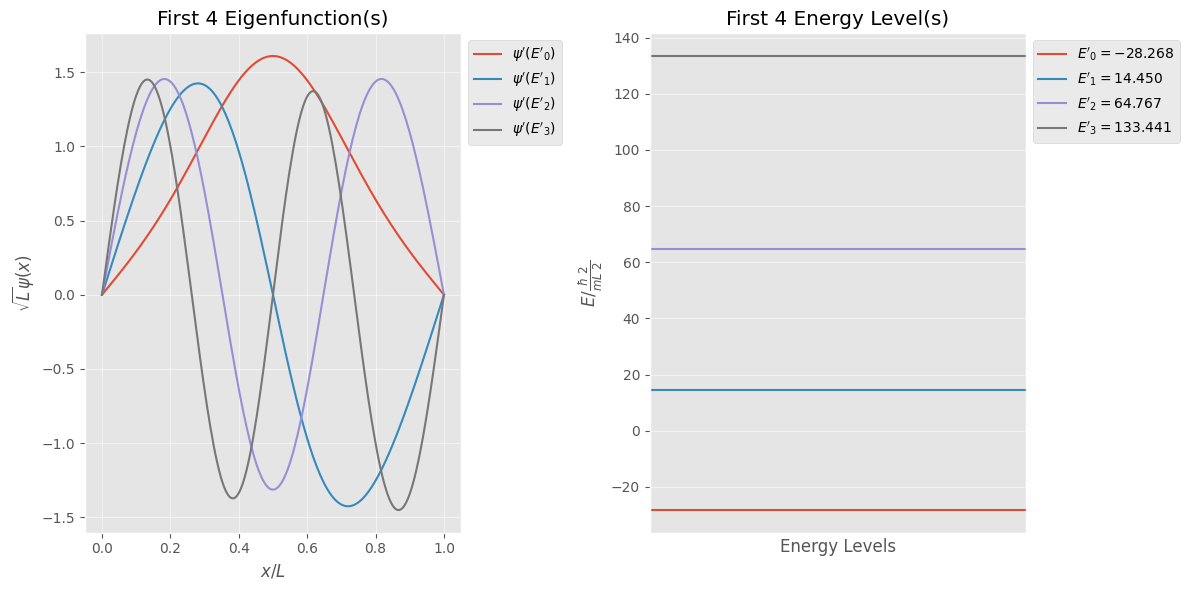

In [3]:
# Gaussian potential well
V_prime = lambda x_prime: - 50 * np.exp(- 0.5 * ((x_prime - 0.5) / 0.2) ** 2)
solver = SchrodingerSolver(V_prime)

solver.find_eigenvalues(E_min = - 200, E_max = 200, n_points = 2_000)
solver.plot_eigenfunctions()

Scanning E values...
E' = -200.000, psi'(1) = 8.505e+03
E' = -169.970, psi'(1) = 2.607e+03
E' = -139.940, psi'(1) = 6.927e+02
E' = -109.910, psi'(1) = 1.485e+02
E' = -79.880, psi'(1) = 2.164e+01
E' = -49.850, psi'(1) = 9.752e-01
E' = -19.820, psi'(1) = -1.291e-01
Found eigenvalue: E' = -40.134
Found eigenvalue: E' = -10.541


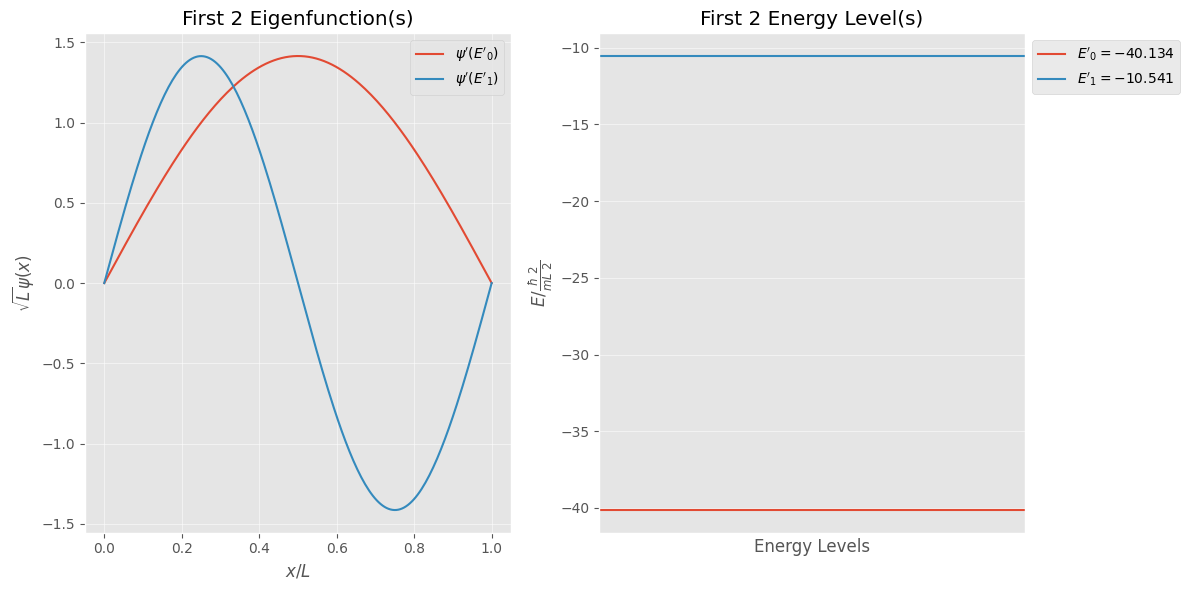

In [4]:
# Constant negative potential
V_prime = lambda _: - 50
solver = SchrodingerSolver(V_prime)

solver.find_eigenvalues(E_min = - 200, E_max = 0, n_points = 1_000)
solver.plot_eigenfunctions()

Scanning E values...
E' = 0.000, psi'(1) = 8.324e+01
E' = 30.030, psi'(1) = 9.761e+00
E' = 60.060, psi'(1) = -9.712e-03
E' = 90.090, psi'(1) = 7.903e-03
E' = 120.120, psi'(1) = 1.035e-01
E' = 150.150, psi'(1) = -5.520e-02
E' = 180.180, psi'(1) = -8.011e-02
Found eigenvalue: E' = 59.866
Found eigenvalue: E' = 89.459
Found eigenvalue: E' = 138.777


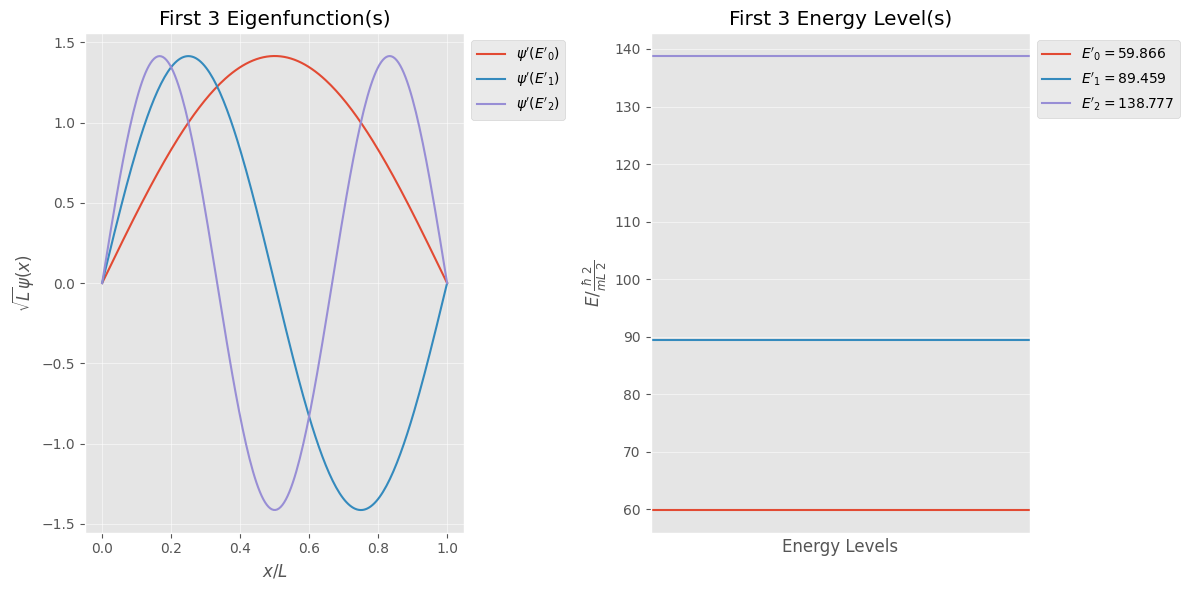

In [5]:
# Constant positive potential
V_prime = lambda _: 50
solver = SchrodingerSolver(V_prime)

solver.find_eigenvalues(E_min = 0, E_max = 200, n_points = 1_000)
solver.plot_eigenfunctions()

Scanning E values...
E' = 0.000, psi'(1) = 1.000e+00
E' = 30.030, psi'(1) = -1.311e-01
E' = 60.060, psi'(1) = 1.284e-01
E' = 90.090, psi'(1) = -7.308e-03
E' = 120.120, psi'(1) = -9.118e-02
E' = 150.150, psi'(1) = -2.485e-02
E' = 180.180, psi'(1) = 5.648e-02
Found eigenvalue: E' = 9.866
Found eigenvalue: E' = 39.459
Found eigenvalue: E' = 88.777
Found eigenvalue: E' = 157.825


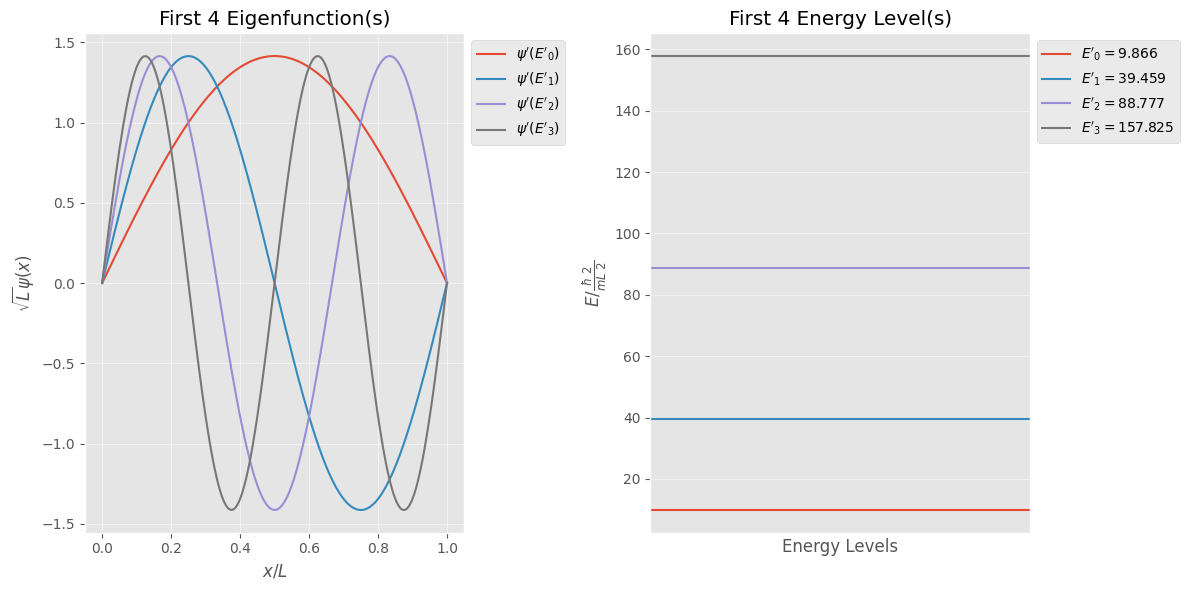

In [6]:
# Free particle
V_prime = lambda _: 0
solver = SchrodingerSolver(V_prime)

solver.find_eigenvalues(E_min = 0, E_max = 200, n_points = 1_000)
solver.plot_eigenfunctions()

In [7]:
# Check the exact solution for the free particle within [0, L]: E' = (n * pi) ^ 2
print(*[f"{(n * np.pi) ** 2:.3f}" for n in range(1, 5, 1)])

9.870 39.478 88.826 157.914


Scanning E values...
E' = -200.000, psi'(1) = 1.083e+05
E' = -169.985, psi'(1) = 4.124e+04
E' = -139.970, psi'(1) = 1.461e+04
E' = -109.955, psi'(1) = 4.726e+03
E' = -79.940, psi'(1) = 1.353e+03
E' = -49.925, psi'(1) = 3.252e+02
E' = -19.910, psi'(1) = 5.866e+01
E' = 10.105, psi'(1) = 5.611e+00
E' = 40.120, psi'(1) = -2.723e-01
E' = 70.135, psi'(1) = 6.017e-02
E' = 100.150, psi'(1) = 8.387e-02
E' = 130.165, psi'(1) = -7.176e-02
E' = 160.180, psi'(1) = -7.062e-02
E' = 190.195, psi'(1) = 2.151e-02
Found eigenvalue: E' = 32.247
Found eigenvalue: E' = 65.164
Found eigenvalue: E' = 114.269
Found eigenvalue: E' = 183.130


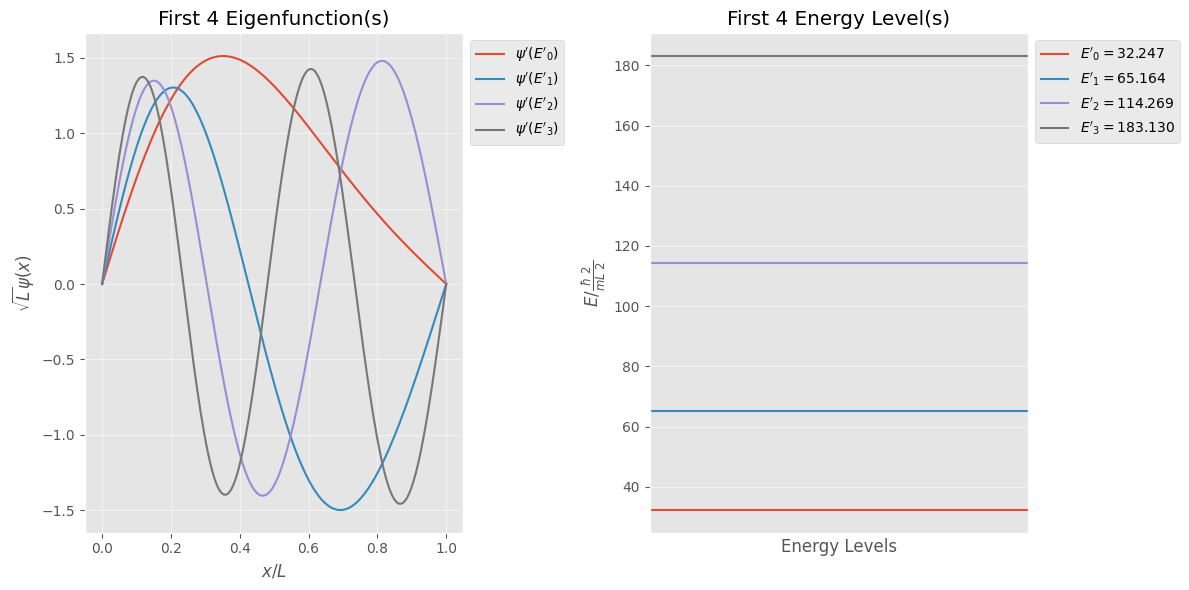

In [8]:
# Linear potential
V_prime = lambda x_prime: 50 * x_prime
solver = SchrodingerSolver(V_prime)

solver.find_eigenvalues(E_min = - 200, E_max = 200, n_points = 2_000)
solver.plot_eigenfunctions()

Scanning E values...
E' = -200.000, psi'(1) = 2.833e+04
E' = -169.985, psi'(1) = 9.746e+03
E' = -139.970, psi'(1) = 3.033e+03
E' = -109.955, psi'(1) = 8.234e+02
E' = -79.940, psi'(1) = 1.825e+02
E' = -49.925, psi'(1) = 2.835e+01
E' = -19.910, psi'(1) = 1.663e+00
E' = 10.105, psi'(1) = -2.034e-01
E' = 40.120, psi'(1) = 1.195e-01
E' = 70.135, psi'(1) = 1.549e-02
E' = 100.150, psi'(1) = -8.832e-02
E' = 130.165, psi'(1) = -3.632e-02
E' = 160.180, psi'(1) = 4.869e-02
E' = 190.195, psi'(1) = 6.649e-02
Found eigenvalue: E' = -7.242
Found eigenvalue: E' = 24.370
Found eigenvalue: E' = 72.894
Found eigenvalue: E' = 141.617


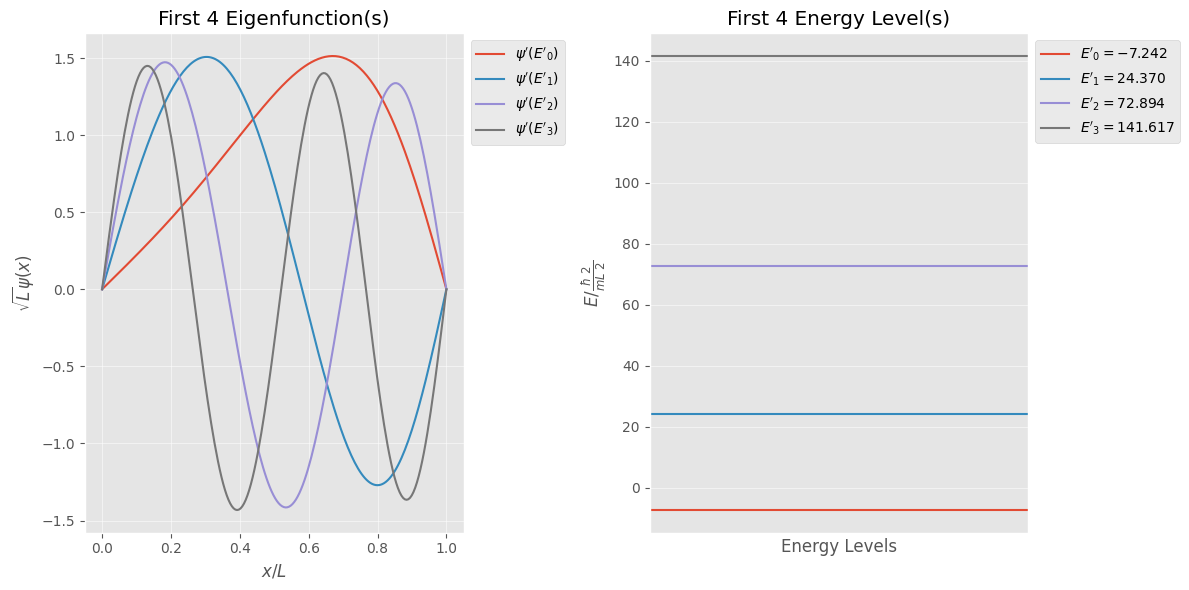

In [9]:
# Harmonic potential
V_prime = lambda x_prime: - 50 * x_prime ** 2
solver = SchrodingerSolver(V_prime)

solver.find_eigenvalues(E_min = - 200, E_max = 200, n_points = 2_000)
solver.plot_eigenfunctions()

Scanning E values...
E' = -200.000, psi'(1) = 1.980e+04
E' = -169.985, psi'(1) = 6.596e+03
E' = -139.970, psi'(1) = 1.947e+03
E' = -109.955, psi'(1) = 4.915e+02
E' = -79.940, psi'(1) = 9.588e+01
E' = -49.925, psi'(1) = 1.170e+01
E' = -19.910, psi'(1) = 1.575e-01
E' = 10.105, psi'(1) = 8.964e-02
E' = 40.120, psi'(1) = 1.816e-01
E' = 70.135, psi'(1) = -3.341e-02
E' = 100.150, psi'(1) = -9.640e-02
E' = 130.165, psi'(1) = -8.642e-03
E' = 160.180, psi'(1) = 6.847e-02
E' = 190.195, psi'(1) = 6.223e-02
Found eigenvalue: E' = -16.794
Found eigenvalue: E' = 4.085
Found eigenvalue: E' = 64.792
Found eigenvalue: E' = 132.654


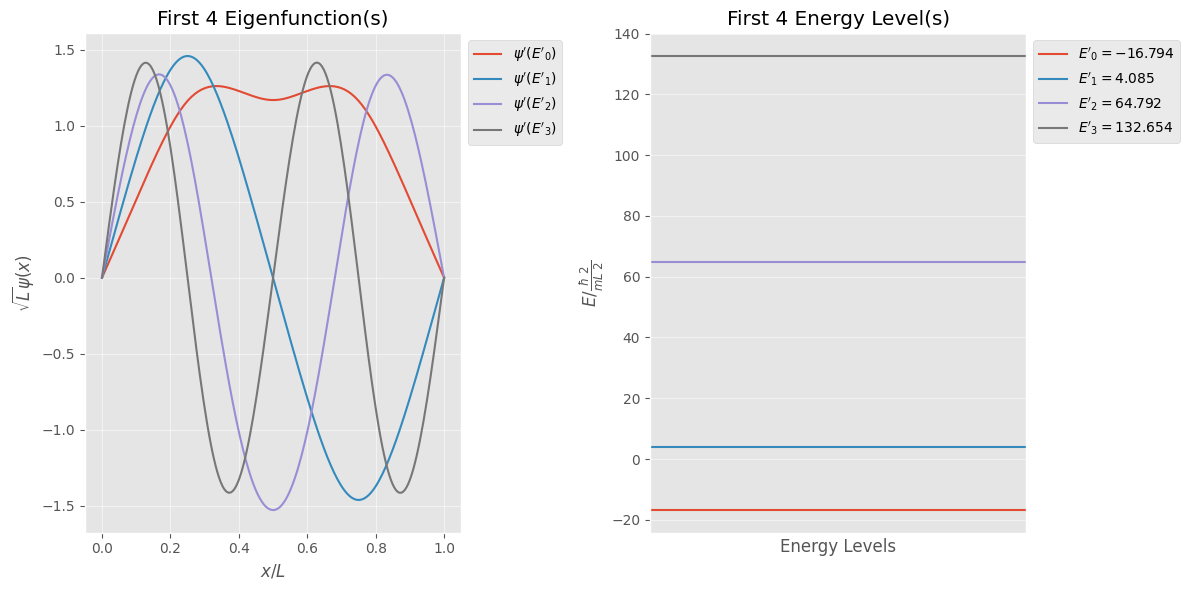

In [10]:
# W potential
V_prime = lambda x_prime: np.where(
    x_prime < 0.5,
    - 50 * (1 - 4 * np.abs(x_prime - 0.25)),  # Left peak centered at 0.25
    - 50 * (1 - 4 * np.abs(x_prime - 0.75))   # Right peak centered at 0.75
)

solver = SchrodingerSolver(V_prime)

solver.find_eigenvalues(E_min = - 200, E_max = 200, n_points = 2_000)
solver.plot_eigenfunctions()